# import data

In [ ]:
import pandas as pd

# -----------------------------------------
# Load both CSV files (fetched from GitHub)
# -----------------------------------------
# Use raw.githubusercontent.com links instead of standard web page links
base_file = "https://raw.githubusercontent.com/Peckkie/Face-Recognition-Statistical-Test-2025/main/result-cal/calculated_distances_effnet_base_8type.csv"
unlearn_file0 = "https://raw.githubusercontent.com/Peckkie/Face-Recognition-Statistical-Test-2025/main/result-cal/type8_combined_calculated_distances.csv"
unlearn_file1 = "https://raw.githubusercontent.com/Peckkie/Face-Recognition-Statistical-Test-2025/main/result-cal/combined_calculated_distances.csv"
df_before = pd.read_csv(base_file)       # EffNet baseline (before unlearning)
df_after0 = pd.read_csv(unlearn_file0)     # EffNet unlearned (after unlearning)
df_after1 = pd.read_csv(unlearn_file1)
df_after = pd.concat([df_after0, df_after1], ignore_index=True)

same_types = [ 5]

df_after_same_types = df_after[df_after["type"].isin(same_types)]

df_before_same_types = df_before[df_before["type"].isin(same_types)]


# Select only the required columns
before = df_before_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# Join on 'path_img1' and 'path_img2'
df_merged_same_types = after.merge(before, on=['path_img1','path_img2'], how='inner')

# -----------------------------------------
# 1) Same person AFTER (unlearning)
# -----------------------------------------
same_person_unlearn = df_merged_same_types["distance_after"].values

# -----------------------------------------
# 2) Same person BEFORE (baseline)
# -----------------------------------------
same_person_baseline = df_merged_same_types["distance_before"].values

# Check data size for each group
print("same_person_baseline:", len(same_person_baseline))
print("same_person_unlearn :", len(same_person_unlearn))

diff_types = [6]

df_after_diff_types = df_after[df_after["type"].isin(diff_types)]
df_before_diff_types = df_before[df_before["type"].isin(diff_types)]


# Select only the required columns
before = df_before_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# merge on 'path_img1' and 'path_img2'
df_merged_diff_types = after.merge(before, on=['path_img1','path_img2'], how='left')

# -----------------------------------------
# 3) Different people  AFTER (unlearning)
# -----------------------------------------
different_person_unlearn = df_merged_diff_types["distance_after"].values
# -----------------------------------------
# 4) Different people BEFORE (baseline)
# -----------------------------------------
different_person_baseline = df_merged_diff_types["distance_before"].values

# Check data counts per group
print("different_person_baseline:", len(different_person_baseline))
print("different_person_unlearn :", len(different_person_unlearn))

same_person_baseline: 8339
same_person_unlearn : 8339
different_person_baseline: 75808
different_person_unlearn : 75808


In [ ]:
print("same_person_baseline:", len(same_person_baseline))
print("same_person_unlearn :", len(same_person_unlearn))

print("different_person_baseline:", len(different_person_baseline))
print("different_person_unlearn :", len(different_person_unlearn))

same_person_baseline: 8339
same_person_unlearn : 8339
different_person_baseline: 75808
different_person_unlearn : 75808


In [ ]:
print("df_before_same_types:", len(df_before_same_types))
print("df_after_same_types :", len(df_after_same_types))

print("df_before_diff_types:", len(df_before_diff_types))
print("df_after_diff_types :", len(df_after_diff_types))

df_before_same_types: 8339
df_after_same_types : 8339
df_before_diff_types: 75808
df_after_diff_types : 75808


In [ ]:
print("Merged same-person pairs :", len(df_merged_same_types))
print("Merged diff-person pairs :", len(df_merged_diff_types))

Merged same-person pairs : 8339
Merged diff-person pairs : 75808


In [ ]:
print(
    df_merged_same_types[['path_img1','path_img2']]
    .drop_duplicates()
    .shape[0]
)

print(
    df_merged_diff_types[['path_img1','path_img2']]
    .drop_duplicates()
    .shape[0]
)

8339
75808


In [ ]:
print(df_before["type"].value_counts())
print(df_after["type"].value_counts())

type
4    121606
3    121598
8     87035
6     75808
7     14902
2     14115
1     13488
5      8339
Name: count, dtype: int64
type
4    121606
3    121598
8     87035
6     75808
7     14902
2     14115
1     13488
5      8339
Name: count, dtype: int64


In [ ]:
print("Total before:", len(df_before))
print("Total after :", len(df_after))

Total before: 456891
Total after : 456891


In [ ]:
len(same_person_baseline)
len(different_person_baseline)

75808

In [ ]:
different_person_unlearn

array([0.85687  , 1.2108383, 1.3613487, ..., 1.5516484, 1.2919457,
       1.6366303])

In [ ]:
different_person_baseline

array([0.15964453, 0.21019672, 0.733774  , ..., 0.9748191 , 0.31381822,
       0.978474  ])

# Test of normality

--- Normality Test for: Same Person (Unlearn) ---
KS statistic: 0.0599
p-value: 0.0000
Result: Same Person (Unlearn) does NOT follow a normal distribution (p < 0.05)



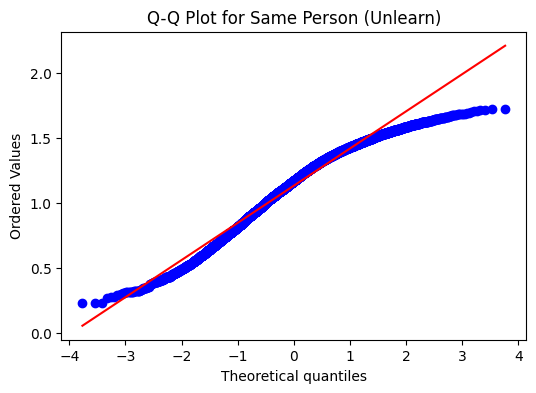

--- Normality Test for: Different Person (Unlearn) ---
KS statistic: 0.1369
p-value: 0.0000
Result: Different Person (Unlearn) does NOT follow a normal distribution (p < 0.05)



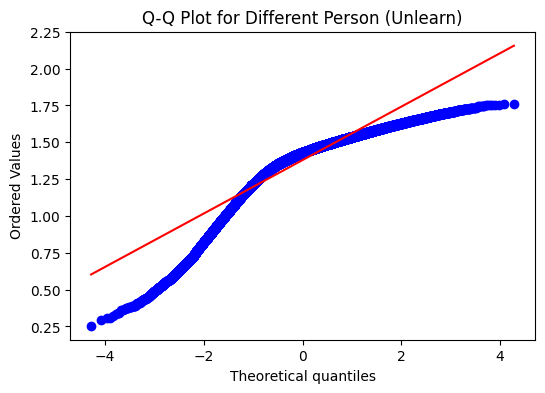

--- Normality Test for: Same Person (Baseline) ---
KS statistic: 0.1002
p-value: 0.0000
Result: Same Person (Baseline) does NOT follow a normal distribution (p < 0.05)



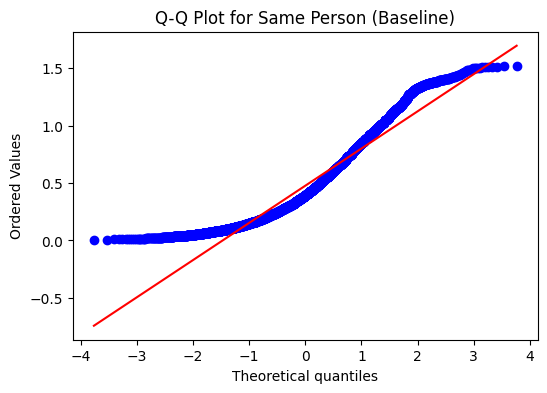

--- Normality Test for: Different Person (Baseline) ---
KS statistic: 0.0842
p-value: 0.0000
Result: Different Person (Baseline) does NOT follow a normal distribution (p < 0.05)



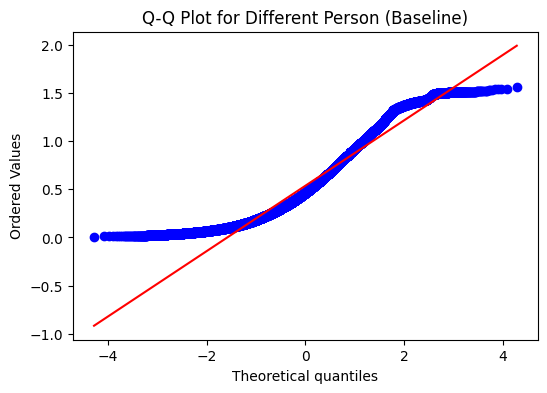

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Drop NaN values for Unlearn group
same_un = same_person_unlearn
diff_un = different_person_unlearn
same_un_clean = same_un[~np.isnan(same_un)]
diff_un_clean = diff_un[~np.isnan(diff_un)]

# 2. Drop NaN values for Baseline group
same_base = same_person_baseline
diff_base = different_person_baseline
same_base_clean = same_base[~np.isnan(same_base)]
diff_base_clean = diff_base[~np.isnan(diff_base)]

def test_normality_and_qq(data, label):
    print(f"--- Normality Test for: {label} ---")
    # Standardization for KS test
    data_std = (data - np.mean(data)) / np.std(data)

    # Kolmogorov-Smirnov test
    ks_stat, p_val = stats.kstest(data_std, 'norm')
    print(f"KS statistic: {ks_stat:.4f}")
    print(f"p-value: {p_val:.4f}")

    if p_val < 0.05:
        print(f"Result: {label} does NOT follow a normal distribution (p < 0.05)\n")
    else:
        print(f"Result: {label} follows a normal distribution (p >= 0.05)\n")

    # Q-Q Plot
    plt.figure(figsize=(6, 4))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {label}")
    plt.show()

# --- Testing for Unlearn group ---
test_normality_and_qq(same_un_clean, "Same Person (Unlearn)")
test_normality_and_qq(diff_un_clean, "Different Person (Unlearn)")

# --- Testing for Baseline group ---
test_normality_and_qq(same_base_clean, "Same Person (Baseline)")
test_normality_and_qq(diff_base_clean, "Different Person (Baseline)")

# plot

ค่า Median ที่คำนวณได้จริงคือ: 0.8791


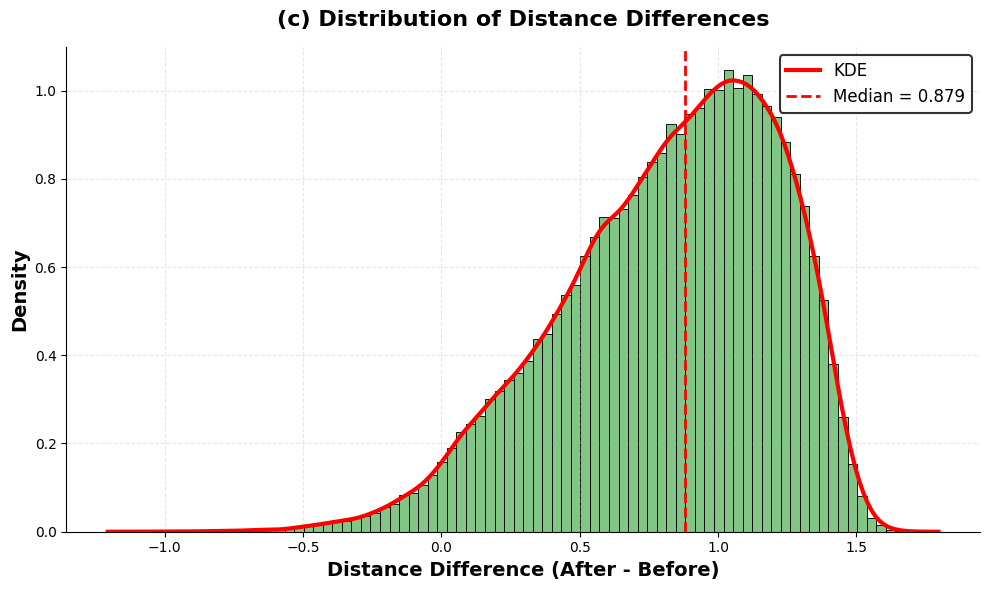

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate Distance Difference (After - Before) from existing variables in Colab
diffs_same = same_person_unlearn - same_person_baseline
diffs_diff = different_person_unlearn - different_person_baseline

# Combine all data (both same person and different people)
all_diffs = np.concatenate([diffs_same, diffs_diff])
all_diffs = all_diffs[~np.isnan(all_diffs)] # Remove NaN values to prevent errors

# >>> Calculate Median from actual data <<<
actual_median = np.median(all_diffs)
print(f"Actual calculated Median: {actual_median:.4f}")

# 2. Set up and plot the graph (right figure)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot traditional green Histogram
sns.histplot(all_diffs, bins=80, color='#4CAF50', stat='density', alpha=0.7, edgecolor='black', ax=ax)

# Plot red KDE line
sns.kdeplot(all_diffs, color='red', linewidth=3, ax=ax, label='KDE')

# >>> Plot dashed line for Median <<<
ax.axvline(actual_median, color='red', linestyle='--', linewidth=2, label=f'Median = {actual_median:.3f}')

# 3. Customize plot style to match the original figure
ax.set_title('(c) Distribution of Distance Differences', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Distance Difference (After - Before)', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')

# Add dashed grid lines
ax.grid(True, linestyle='--', alpha=0.3)

# Handle plot borders (remove top and right spines for a clean look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend for both KDE and Median
legend = ax.legend(fontsize=12, loc='upper right', frameon=True, edgecolor='black')
legend.get_frame().set_linewidth(1.5)

plt.tight_layout()

# 4. Save the figure as a PNG file for the paper
plt.savefig('Figure_3c_with_median.png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

#identity

In [ ]:
import numpy as np
from scipy import stats
import math
from decimal import Decimal, getcontext

getcontext().prec = 500

# -------------------------------------------------
# Extract identity from path
# Example: .../271/L/134029.jpg → "271"
# -------------------------------------------------
def extract_identity(path):
    return str(path).split('/')[-2]

# -------------------------------------------------
# Copy source DataFrames and assign identities
# (df_merged_same_types and df_merged_diff_types
#  must contain columns: path_img1, path_img2,
#  distance_before, distance_after)
# -------------------------------------------------
df_same = df_merged_same_types.copy()
df_diff = df_merged_diff_types.copy()

df_same['id1'] = df_same['path_img1'].apply(extract_identity)
df_same['id2'] = df_same['path_img2'].apply(extract_identity)
df_diff['id1'] = df_diff['path_img1'].apply(extract_identity)
df_diff['id2'] = df_diff['path_img2'].apply(extract_identity)

all_ids = np.array(sorted(
    set(df_same['id1']) | set(df_same['id2']) |
    set(df_diff['id1']) | set(df_diff['id2'])
))
print(f"จำนวน identities ทั้งหมด: {len(all_ids)}")


จำนวน identities ทั้งหมด: 30


In [ ]:
print(df_merged_same_types['path_img1'].iloc[0])
print(df_merged_same_types['path_img2'].iloc[0])
print(df_merged_diff_types['path_img1'].iloc[0])

/media/HDD/tripletloss_dataset/CelebA/7_type/test_set1/Non_LR/271/134029.jpg
/media/HDD/tripletloss_dataset/CelebA/7_type/test_set1/Non_LR/271/042390.jpg
/media/HDD/tripletloss_dataset/CelebA/7_type/test_set1/Non_LR/271/134029.jpg


## RQ1: Same vs. Different Person Distances
- Table 5 summarizes the Mann–Whitney U tests for comparing Dsame and Ddiff within each model.

In [ ]:
import numpy as np
from scipy import stats
import math
from decimal import Decimal, getcontext

getcontext().prec = 500

# -------------------------------------------------
# Extract identity from path
# Example: .../271/134029.jpg → "271"
# -------------------------------------------------
def extract_identity(path):
    return str(path).split('/')[-2]

# -------------------------------------------------
# Prepare DataFrame and assign identities
# (Assumes df_merged_same_types and df_merged_diff_types are already defined)
# -------------------------------------------------
df_same = df_merged_same_types.copy()
df_diff = df_merged_diff_types.copy()

df_same['id1'] = df_same['path_img1'].apply(extract_identity)
df_same['id2'] = df_same['path_img2'].apply(extract_identity)
df_diff['id1'] = df_diff['path_img1'].apply(extract_identity)
df_diff['id2'] = df_diff['path_img2'].apply(extract_identity)

all_ids = np.array(sorted(
    set(df_same['id1']) | set(df_same['id2']) |
    set(df_diff['id1']) | set(df_diff['id2'])
))
print(f"Total number of identities: {len(all_ids)}")

# -------------------------------------------------
# Data cleaning function
# -------------------------------------------------
def process_data(data):
    arr = np.array(data, dtype=float)
    return arr[~np.isnan(arr)]

# -------------------------------------------------
# Identity-level Bootstrap MWU
# -------------------------------------------------
def analyze_mwu(df_diff_full, df_same_full,
                dist_col, label,
                n_bootstraps=20000, seed=42):
    rng = np.random.default_rng(seed)
    n_ids = len(all_ids)

    boot_Z_vals    = []
    boot_cles_vals = []

    # Fetch values as arrays once before entering the loop for performance
    same_id1 = df_same_full['id1'].values
    same_dist = df_same_full[dist_col].values

    diff_id1 = df_diff_full['id1'].values
    diff_id2 = df_diff_full['id2'].values
    diff_dist = df_diff_full[dist_col].values

    for _ in range(n_bootstraps):
        # Resample identities with replacement
        boot_ids = rng.choice(all_ids, size=n_ids, replace=True)

        # Count the frequency of each sampled identity
        unique_ids, counts = np.unique(boot_ids, return_counts=True)
        id_weights = dict(zip(unique_ids, counts))

        # Assign weights to each image pair
        w_same = np.array([id_weights.get(i, 0) for i in same_id1])
        w_diff1 = np.array([id_weights.get(i, 0) for i in diff_id1])
        w_diff2 = np.array([id_weights.get(i, 0) for i in diff_id2])
        w_diff = w_diff1 * w_diff2

        # Expand arrays based on frequency weights
        b_same = np.repeat(same_dist, w_same)
        b_diff = np.repeat(diff_dist, w_diff)

        # Remove NaN values
        b_same = b_same[~np.isnan(b_same)]
        b_diff = b_diff[~np.isnan(b_diff)]

        if len(b_same) < 5 or len(b_diff) < 5:
            continue

        U_b, _ = stats.mannwhitneyu(b_diff, b_same, alternative='greater')
        n_s, n_d = len(b_same), len(b_diff)
        mean_U_b = (n_d * n_s) / 2.0
        sd_U_b   = np.sqrt((n_d * n_s * (n_d + n_s + 1)) / 12.0)
        boot_Z_vals.append((U_b - mean_U_b) / sd_U_b)
        boot_cles_vals.append(U_b / (n_d * n_s))

    boot_Z_arr    = np.array(boot_Z_vals)
    boot_cles_arr = np.array(boot_cles_vals)

    # --- Statistical summary from actual full data (point estimate) ---
    same_all = process_data(df_same_full[dist_col].values)
    diff_all = process_data(df_diff_full[dist_col].values)
    n_same, n_diff = len(same_all), len(diff_all)
    N_total = n_same + n_diff

    mean_same = same_all.mean()
    med_same  = np.median(same_all)
    mean_diff = diff_all.mean()
    med_diff  = np.median(diff_all)

    U, _ = stats.mannwhitneyu(diff_all, same_all, alternative='greater')
    mean_U = (n_diff * n_same) / 2.0
    sd_U   = np.sqrt((n_diff * n_same * (N_total + 1)) / 12.0)
    Z      = (U - mean_U) / sd_U

    if Z > 10.0:
        z_dec  = Decimal(float(Z))
        pi_dec = Decimal(math.pi)
        log_p  = -(z_dec**2) / Decimal(2) - (z_dec.ln() + (Decimal(2) * pi_dec).sqrt().ln())
        p_exact = log_p.exp()
    else:
        p_exact = Decimal(float(1 - stats.norm.cdf(Z)))

    cles        = U / (n_diff * n_same)
    cliff_delta = (2 * cles) - 1
    r           = abs(Z) / np.sqrt(N_total)

    # --- Bootstrap Confidence Interval (95% CI) ---
    Z_ci     = np.percentile(boot_Z_arr,    [2.5, 97.5])
    cles_ci  = np.percentile(boot_cles_arr, [2.5, 97.5])
    cliff_ci = (2 * cles_ci) - 1

    # --- Bootstrap p-value (Normal approximation) ---
    boot_mean = np.mean(boot_Z_arr)
    boot_std  = np.std(boot_Z_arr, ddof=1)
    Z_boot    = float(boot_mean / boot_std)

    if Z_boot > 10.0:
        Z_dec  = Decimal(Z_boot)
        pi_dec = Decimal(math.pi)
        log_p  = -(Z_dec**2) / Decimal(2) - (Z_dec.ln() + (Decimal(2) * pi_dec).sqrt().ln())
        p_boot_exact = log_p.exp()
    else:
        p_boot_exact = Decimal(float(stats.norm.sf(Z_boot)))

    p_boot_str = f"{p_boot_exact:.5e}".replace("e", " x 10^")

    # --- Print Outputs ---
    print(f"=== Mann-Whitney U test: Diff > Same ({label}) [Identity-level Bootstrap, n={len(boot_Z_arr)}] ===")
    print(f"Same - Mean: {mean_same:.4f} | Median: {med_same:.4f}")
    print(f"Diff - Mean: {mean_diff:.4f} | Median: {med_diff:.4f}")
    print(f"U = {U}")
    print(f"Z = {Z:.15f}")
    print(f"p-value (one-sided, exact)   = {p_exact:.15e}")
    print(f"Bootstrap p-value (exact)    = {p_boot_str}  (Z_boot = {Z_boot:.4f})")
    print(f"CLES = {cles:.10f}  95% CI [{cles_ci[0]:.6f}, {cles_ci[1]:.6f}]")
    print(f"Cliff's Delta = {cliff_delta:.10f}  95% CI [{cliff_ci[0]:.6f}, {cliff_ci[1]:.6f}]")
    print(f"r = {r:.10f}")
    print(f"Z 95% CI (Bootstrap) = [{Z_ci[0]:.4f}, {Z_ci[1]:.4f}]\n")

# -------------------------------------------------
# Run Analysis
# -------------------------------------------------
analyze_mwu(df_diff, df_same, dist_col='distance_before', label='Baseline')
analyze_mwu(df_diff, df_same, dist_col='distance_after',  label='Unlearn')

จำนวน identities ทั้งหมด: 30
=== Mann-Whitney U test: Diff > Same (Baseline) [Identity-level Bootstrap, n=20000] ===
Same - Mean: 0.4763 | Median: 0.3914
Diff - Mean: 0.5369 | Median: 0.4641
U = 349921661.0
Z = 16.072639458700550
p-value (one-sided, exact)   = 1.991740464788230e-58
Bootstrap p-value (exact)    = 1.96458 x 10^-3  (Z_boot = 2.8838)
CLES = 0.5535308294  95% CI [0.518602, 0.591453]
Cliff's Delta = 0.1070616588  95% CI [0.037204, 0.182906]
r = 0.0554074144
Z 95% CI (Bootstrap) = [5.6169, 27.3473]

=== Mann-Whitney U test: Diff > Same (Unlearn) [Identity-level Bootstrap, n=20000] ===
Same - Mean: 1.1329 | Median: 1.1695
Diff - Mean: 1.3794 | Median: 1.4295
U = 484444867.5
Z = 79.965366967379126
p-value (one-sided, exact)   = 1.441054417018940e-1391
Bootstrap p-value (exact)    = 3.15512 x 10^-25  (Z_boot = 10.3115)
CLES = 0.7663291508  95% CI [0.716193, 0.812662]
Cliff's Delta = 0.5326583015  95% CI [0.432386, 0.625323]
r = 0.2756656264
Z 95% CI (Bootstrap) = [64.2566, 94.79

## RQ2: Does the Unlearn model yield larger pairwise separation than the Baseline model?

In [ ]:
import numpy as np
from scipy import stats
from decimal import Decimal, getcontext
import math
from tqdm import tqdm

getcontext().prec = 500

# -------------------------------------------------
# 1) Prepare DataFrame and assign identities
# -------------------------------------------------
def extract_identity(path):
    return str(path).split('/')[-2]

df_same = df_merged_same_types.copy()
df_diff = df_merged_diff_types.copy()

df_same['id1'] = df_same['path_img1'].apply(extract_identity)
df_same['id2'] = df_same['path_img2'].apply(extract_identity)
df_diff['id1'] = df_diff['path_img1'].apply(extract_identity)
df_diff['id2'] = df_diff['path_img2'].apply(extract_identity)

all_ids = np.array(sorted(
    set(df_same['id1']) | set(df_same['id2']) |
    set(df_diff['id1']) | set(df_diff['id2'])
))
print(f"จำนวน identities ทั้งหมด: {len(all_ids)}")

# -------------------------------------------------
# 2) Point estimates from the full dataset
# -------------------------------------------------
def clean(arr):
    a = np.asarray(arr, dtype=float)
    return a[~np.isnan(a)]

same_base_all = clean(df_same['distance_before'].values)
diff_base_all = clean(df_diff['distance_before'].values)
same_un_all   = clean(df_same['distance_after'].values)
diff_un_all   = clean(df_diff['distance_after'].values)

S_base_actual  = np.median(diff_base_all) - np.median(same_base_all)
S_un_actual    = np.median(diff_un_all)   - np.median(same_un_all)
delta_S_actual = S_un_actual - S_base_actual

N_APPROX = 20000
rng = np.random.default_rng(42)

idx_sb = rng.integers(0, len(same_base_all), size=N_APPROX)
idx_db = rng.integers(0, len(diff_base_all), size=N_APPROX)
idx_su = rng.integers(0, len(same_un_all),   size=N_APPROX)
idx_du = rng.integers(0, len(diff_un_all),   size=N_APPROX)

base_vals    = diff_base_all[idx_db] - same_base_all[idx_sb]
unlearn_vals = diff_un_all[idx_du]   - same_un_all[idx_su]

U, _ = stats.mannwhitneyu(unlearn_vals, base_vals, alternative="greater")
cles        = float(U) / (N_APPROX * N_APPROX)
cliff_delta = (2 * cles) - 1

# -------------------------------------------------
# 3) Identity-level Bootstrap
# -------------------------------------------------
N_BOOTSTRAPS = 20000
n_ids = len(all_ids)
bootstrap_delta_S = []

# Pre-extract values as arrays once before the loop for performance
same_id1 = df_same['id1'].values
diff_id1 = df_diff['id1'].values
diff_id2 = df_diff['id2'].values

same_base = df_same['distance_before'].values
diff_base = df_diff['distance_before'].values
same_un   = df_same['distance_after'].values
diff_un   = df_diff['distance_after'].values

print("Running Identity-level Bootstrap (20000 iterations)...")
for i in tqdm(range(N_BOOTSTRAPS)):
    boot_ids = rng.choice(all_ids, size=n_ids, replace=True)
    unique_ids, counts = np.unique(boot_ids, return_counts=True)
    id_weights = dict(zip(unique_ids, counts))

    w_same = np.array([id_weights.get(x, 0) for x in same_id1])
    w_diff1 = np.array([id_weights.get(x, 0) for x in diff_id1])
    w_diff2 = np.array([id_weights.get(x, 0) for x in diff_id2])
    w_diff = w_diff1 * w_diff2

    b_same_base = np.repeat(same_base, w_same)
    b_diff_base = np.repeat(diff_base, w_diff)
    b_same_un   = np.repeat(same_un, w_same)
    b_diff_un   = np.repeat(diff_un, w_diff)

    b_same_base = b_same_base[~np.isnan(b_same_base)]
    b_diff_base = b_diff_base[~np.isnan(b_diff_base)]
    b_same_un   = b_same_un[~np.isnan(b_same_un)]
    b_diff_un   = b_diff_un[~np.isnan(b_diff_un)]

    if len(b_same_base) < 5 or len(b_diff_base) < 5:
        continue

    b_S_base = np.median(b_diff_base) - np.median(b_same_base)
    b_S_un   = np.median(b_diff_un)   - np.median(b_same_un)
    bootstrap_delta_S.append(b_S_un - b_S_base)

bootstrap_delta_S = np.array(bootstrap_delta_S)

# -------------------------------------------------
# 4) Confidence Intervals (CI) and Exact p-value from Bootstrap
# -------------------------------------------------
ci_lower = np.percentile(bootstrap_delta_S, 2.5)
ci_upper = np.percentile(bootstrap_delta_S, 97.5)

boot_mean = np.mean(bootstrap_delta_S)
boot_std  = np.std(bootstrap_delta_S, ddof=1)
Z_boot    = float(boot_mean / boot_std)

if Z_boot > 10.0:
    Z_dec  = Decimal(Z_boot)
    pi_dec = Decimal(math.pi)
    log_p  = -(Z_dec**2) / Decimal(2) - (Z_dec.ln() + (Decimal(2) * pi_dec).sqrt().ln())
    p_exact = log_p.exp()
else:
    p_exact = Decimal(float(stats.norm.sf(Z_boot)))

# -------------------------------------------------
# 5) Print Table 6
# -------------------------------------------------
alpha = Decimal("0.05")
decision   = "Reject H0"       if p_exact < alpha else "Fail to reject H0"
conclusion = "Unlearn > Base (significant)" if p_exact < alpha else "Unlearn <= Base (not sig.)"

p_str = f"{p_exact:.4e}".replace("e", " x 10^")
U_str = f"{U / 1e8:.8f} x 10^8" if U >= 1e8 else f"{U}"

print("\nTable 6: RQ2: Bootstrap Analysis and Effect Sizes on Separation Scores.")
print("-" * 75)
print(f"{'Metric':<40} | {'Value'}")
print("-" * 75)
print(f"{'Median Separation (Base)':<40} | {S_base_actual:.4f}")
print(f"{'Median Separation (Unlearn)':<40} | {S_un_actual:.4f}")
print(f"{'Median ΔS':<40} | {delta_S_actual:.4f}")
print(f"{'CLES':<40} | {cles:.4f}")
print(f"{'Cliff\'s Delta':<40} | {cliff_delta:.4f}")
print(f"{'U statistic (Monte Carlo)':<40} | {U_str}")
print(f"{'95% CI of ΔS [Identity-level]':<40} | [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"{'Bootstrap Z-score':<40} | {Z_boot:.2f}")
print(f"{'Exact p-value (one-sided)':<40} | {p_str}")
print(f"{'Decision':<40} | {decision}")
print(f"{'Conclusion':<40} | {conclusion}")
print("-" * 75)

จำนวน identities ทั้งหมด: 30
Running Identity-level Bootstrap (20000 iterations)...


100%|██████████| 20000/20000 [09:22<00:00, 35.53it/s]


Table 6: RQ2: Bootstrap Analysis and Effect Sizes on Separation Scores.
---------------------------------------------------------------------------
Metric                                   | Value
---------------------------------------------------------------------------
Median Separation (Base)                 | 0.0728
Median Separation (Unlearn)              | 0.2600
Median ΔS                                | 0.1872
CLES                                     | 0.6262
Cliff's Delta                            | 0.2524
U statistic (Monte Carlo)                | 2.50473142 x 10^8
95% CI of ΔS [Identity-level]            | [0.1168, 0.2502]
Bootstrap Z-score                        | 5.48
Exact p-value (one-sided)                | 2.1124 x 10^-8
Decision                                 | Reject H0
Conclusion                               | Unlearn > Base (significant)
---------------------------------------------------------------------------
